# Reading and Merging Copernicus Marine NetCDF Datasets for Aruba (Complete Dataset)

This notebook demonstrates how to:
1. Download physical and biogeochemical datasets for Aruba from Copernicus Marine Service using the `copernicusmarine` Python API
2. Load and merge the two datasets in Pandas by aligning their coordinates and timestamps
3. Calculate current velocity (`speed` in cm/s) and `direction` (in degrees)
4. Display summary statistics and visualize distributions for the entire dataset, including physical (speed, direction, salinity, temperature) and chemical (pH, Dissic, Talk) variables
5. Plot monthly distributions of all variables across all 48 months in the dataset
6. Subset the dataset into years (`year1`, `year2`, `year3`, and an 11-month `year4`) starting from the initial timestamp
7. Display summary statistics and visualize distributions for individual years

In [1]:
import copernicusmarine
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Download Data via Copernicus Marine API
We use `copernicusmarine.subset` to download the specific physical and biogeochemical datasets for Aruba's coordinates:
- **Coordinates:** N: `12.7283`, S: `12.3079`, W: `-70.2344`, E: `-69.6422`
- **Time Range:** July 4, 2022 to June 4, 2026
- **Depth:** `0.49` meters

*Note: Make sure you have run `copernicusmarine login` in your terminal to save your credentials before running this cell.*

In [2]:
# 1. Download Physical Dataset (uo, vo, so, thetao)
print('Downloading physical dataset...')
copernicusmarine.subset(
    dataset_id='cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',
    variables=['uo', 'vo', 'so', 'thetao'],
    minimum_longitude=-70.2344,
    maximum_longitude=-69.6422,
    minimum_latitude=12.3079,
    maximum_latitude=12.7283,
    start_datetime='2022-07-04T12:00:00',
    end_datetime='2026-06-04T12:00:00',
    minimum_depth=0.49,
    maximum_depth=0.5,
    output_directory='.',
    output_filename='aruba_phy.nc',
    force_download=True
)

# 2. Download Biogeochemical Dataset (ph, dissic, talk)
print('Downloading biogeochemical dataset...')
copernicusmarine.subset(
    dataset_id='cmems_mod_glo_bgc-car_anfc_0.25deg_P1D-m',
    variables=['ph', 'dissic', 'talk'],
    minimum_longitude=-70.2344,
    maximum_longitude=-69.6422,
    minimum_latitude=12.3079,
    maximum_latitude=12.7283,
    start_datetime='2022-07-04T12:00:00',
    end_datetime='2026-06-04T12:00:00',
    minimum_depth=0.49,
    maximum_depth=0.5,
    output_directory='.',
    output_filename='aruba_bgc.nc',
    force_download=True
)
print('All downloads complete!')

WARNING - 2026-06-04T00:33:05Z - 'force_download' has been deprecated.


INFO - 2026-06-04T00:33:41Z - Selected dataset version: "202406"
INFO - 2026-06-04T00:33:41Z - Selected dataset part: "default"
WARNING - 2026-06-04T00:33:41Z - Some of your subset selection [0.49, 0.5] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]
100%|██████████| [11:07<00:00]  
INFO - 2026-06-04T00:45:07Z - Total size of the download: 18.37 MB.
WARNING - 2026-06-04T00:45:07Z - 'force_download' has been deprecated.


INFO - 2026-06-04T00:45:44Z - Selected dataset version: "202311"
INFO - 2026-06-04T00:45:44Z - Selected dataset part: "default"
WARNING - 2026-06-04T00:45:44Z - Some of your subset selection [0.49, 0.5] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]
INFO - 2026-06-04T00:53:51Z - Total size of the download: 46.87 KB.


All downloads complete!


### 2. Load and Merge Datasets
We load both NetCDF files, convert them to DataFrames, align their dates, round the latitude/longitude coordinates to avoid floating-point mismatch, and perform an inner merge to combine the physical and biogeochemical datasets.

In [3]:
# Load datasets
ds_phy = xr.open_dataset('aruba_phy.nc')
ds_bgc = xr.open_dataset('aruba_bgc.nc')

# Convert to DataFrames
df_phy = ds_phy.to_dataframe().reset_index()
df_bgc = ds_bgc.to_dataframe().reset_index()

# Align times (convert hourly physics timestamps to date to match daily biogeochemistry)
df_phy['date'] = df_phy['time'].dt.date
df_bgc['date'] = df_bgc['time'].dt.date

# Round latitudes and longitudes to 3 decimal places to avoid floating point coordinates mismatch
df_phy['lat_round'] = df_phy['latitude'].round(3)
df_phy['lon_round'] = df_longitude = df_phy['longitude'].round(3)
df_bgc['lat_round'] = df_bgc['latitude'].round(3)
df_bgc['lon_round'] = df_bgc['longitude'].round(3)

# Merge DataFrames
df = pd.merge(
    df_phy,
    df_bgc[['date', 'lat_round', 'lon_round', 'ph', 'dissic', 'talk']],
    on=['date', 'lat_round', 'lon_round'],
    how='inner'
)

print('Data merging complete!')
df.head()

Data merging complete!


,time,depth,latitude,longitude,uo,vo,so,thetao,date,lat_round,lon_round,ph,dissic,talk
0,2022-07-05 00:00:00,0.494025,12.5,-70.00,-0.384954,-0.074150,36.949310,26.474485,2022-07-05,12.5,-70.00,8.026987,2.081415,2.425763
1,2022-07-05 00:00:00,0.494025,12.5,-69.75,-0.337544,0.412268,37.066238,26.810297,2022-07-05,12.5,-69.75,8.026102,2.078316,2.423807
2,2022-07-05 01:00:00,0.494025,12.5,-70.00,-0.385204,-0.072764,36.949127,26.463650,2022-07-05,12.5,-70.00,8.026987,2.081415,2.425763
3,2022-07-05 01:00:00,0.494025,12.5,-69.75,-0.338240,0.410602,37.071140,26.799545,2022-07-05,12.5,-69.75,8.026102,2.078316,2.423807
4,2022-07-05 02:00:00,0.494025,12.5,-70.00,-0.384573,-0.069373,36.949257,26.449852,2022-07-05,12.5,-70.00,8.026987,2.081415,2.425763


### 3. Calculate Velocity and Direction of the Currents
We calculate the current speed (scaled to **cm/s**) and direction (in degrees relative to North).

In [4]:
# 1. Calculate Vector Magnitude (Sea Water Speed) in m/s
df['speed'] = np.sqrt(df['uo']**2 + df['vo']**2)

# 2. Convert Speed to cm/s for clean integer ticks on x-axis
df['speed_cms'] = df['speed'] * 100

# 3. Calculate Vector Direction in Degrees (Oceanographic convention: 0° = North, 90° = East)
sea_water_dir = np.degrees(np.arctan2(df['uo'], df['vo']))
df['direction'] = (sea_water_dir + 360) % 360

print('Calculations complete!')
df[['time', 'latitude', 'longitude', 'uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao', 'ph', 'dissic', 'talk']].head()

Calculations complete!


,time,latitude,longitude,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
0,2022-07-05 00:00:00,12.5,-70.00,-0.384954,-0.074150,39.203079,259.097229,36.949310,26.474485,8.026987,2.081415,2.425763
1,2022-07-05 00:00:00,12.5,-69.75,-0.337544,0.412268,53.282349,320.691071,37.066238,26.810297,8.026102,2.078316,2.423807
2,2022-07-05 01:00:00,12.5,-70.00,-0.385204,-0.072764,39.201622,259.303040,36.949127,26.463650,8.026987,2.081415,2.425763
3,2022-07-05 01:00:00,12.5,-69.75,-0.338240,0.410602,53.197742,320.519501,37.071140,26.799545,8.026102,2.078316,2.423807
4,2022-07-05 02:00:00,12.5,-70.00,-0.384573,-0.069373,39.077995,259.774445,36.949257,26.449852,8.026987,2.081415,2.425763


### 4. Inspect DataFrame Info & Summary Statistics (Entire Dataset)
Understand columns, counts, and view the summary statistics for physical and chemical variables.

In [5]:
print('--- DataFrame Info ---')
df.info()

print('\n--- Summary Statistics (Entire Dataset) ---')
display(df[['uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao', 'ph', 'dissic', 'talk']].describe())

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 68666 entries, 0 to 68665
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   time       68666 non-null  datetime64[ns]
 1   depth      68666 non-null  float32       
 2   latitude   68666 non-null  float32       
 3   longitude  68666 non-null  float32       
 4   uo         68666 non-null  float32       
 5   vo         68666 non-null  float32       
 6   so         68666 non-null  float32       
 7   thetao     68666 non-null  float32       
 8   date       68666 non-null  object        
 9   lat_round  68666 non-null  float32       
 10  lon_round  68666 non-null  float32       
 11  ph         68666 non-null  float32       
 12  dissic     68666 non-null  float32       
 13  talk       68666 non-null  float32       
 14  speed      68666 non-null  float32       
 15  speed_cms  68666 non-null  float32       
 16  direction  68666 non-null  f

,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
count,68666.000000,68666.000000,68666.000000,68666.000000,68666.000000,68666.000000,68666.000000,68666.000000,68666.000000
mean,-0.365314,0.238302,50.435463,283.840240,36.290058,27.815594,8.019414,2.071864,2.416177
std,0.220186,0.285469,25.659637,57.242916,0.685526,1.279668,0.011353,0.027409,0.024649
min,-1.086100,-0.586683,0.587690,0.001587,32.841969,24.577477,7.989708,1.991114,2.328858
25%,-0.513324,0.039015,31.069048,274.429741,36.059472,26.798062,8.011786,2.057833,2.407652
50%,-0.362434,0.172115,47.356895,291.886368,36.485872,27.723588,8.017678,2.077940,2.424054
75%,-0.224804,0.415177,65.754421,317.655495,36.711450,28.745987,8.026316,2.091240,2.433213
max,0.479030,1.445309,165.142136,359.998474,37.717453,31.450548,8.052398,2.129844,2.450076


### 5. Visualize Distributions (Entire Dataset)
Plot a 4x2 grid of histograms for all physical and environmental variables in the entire dataset, optimized with correct units and ticks for Aruba.

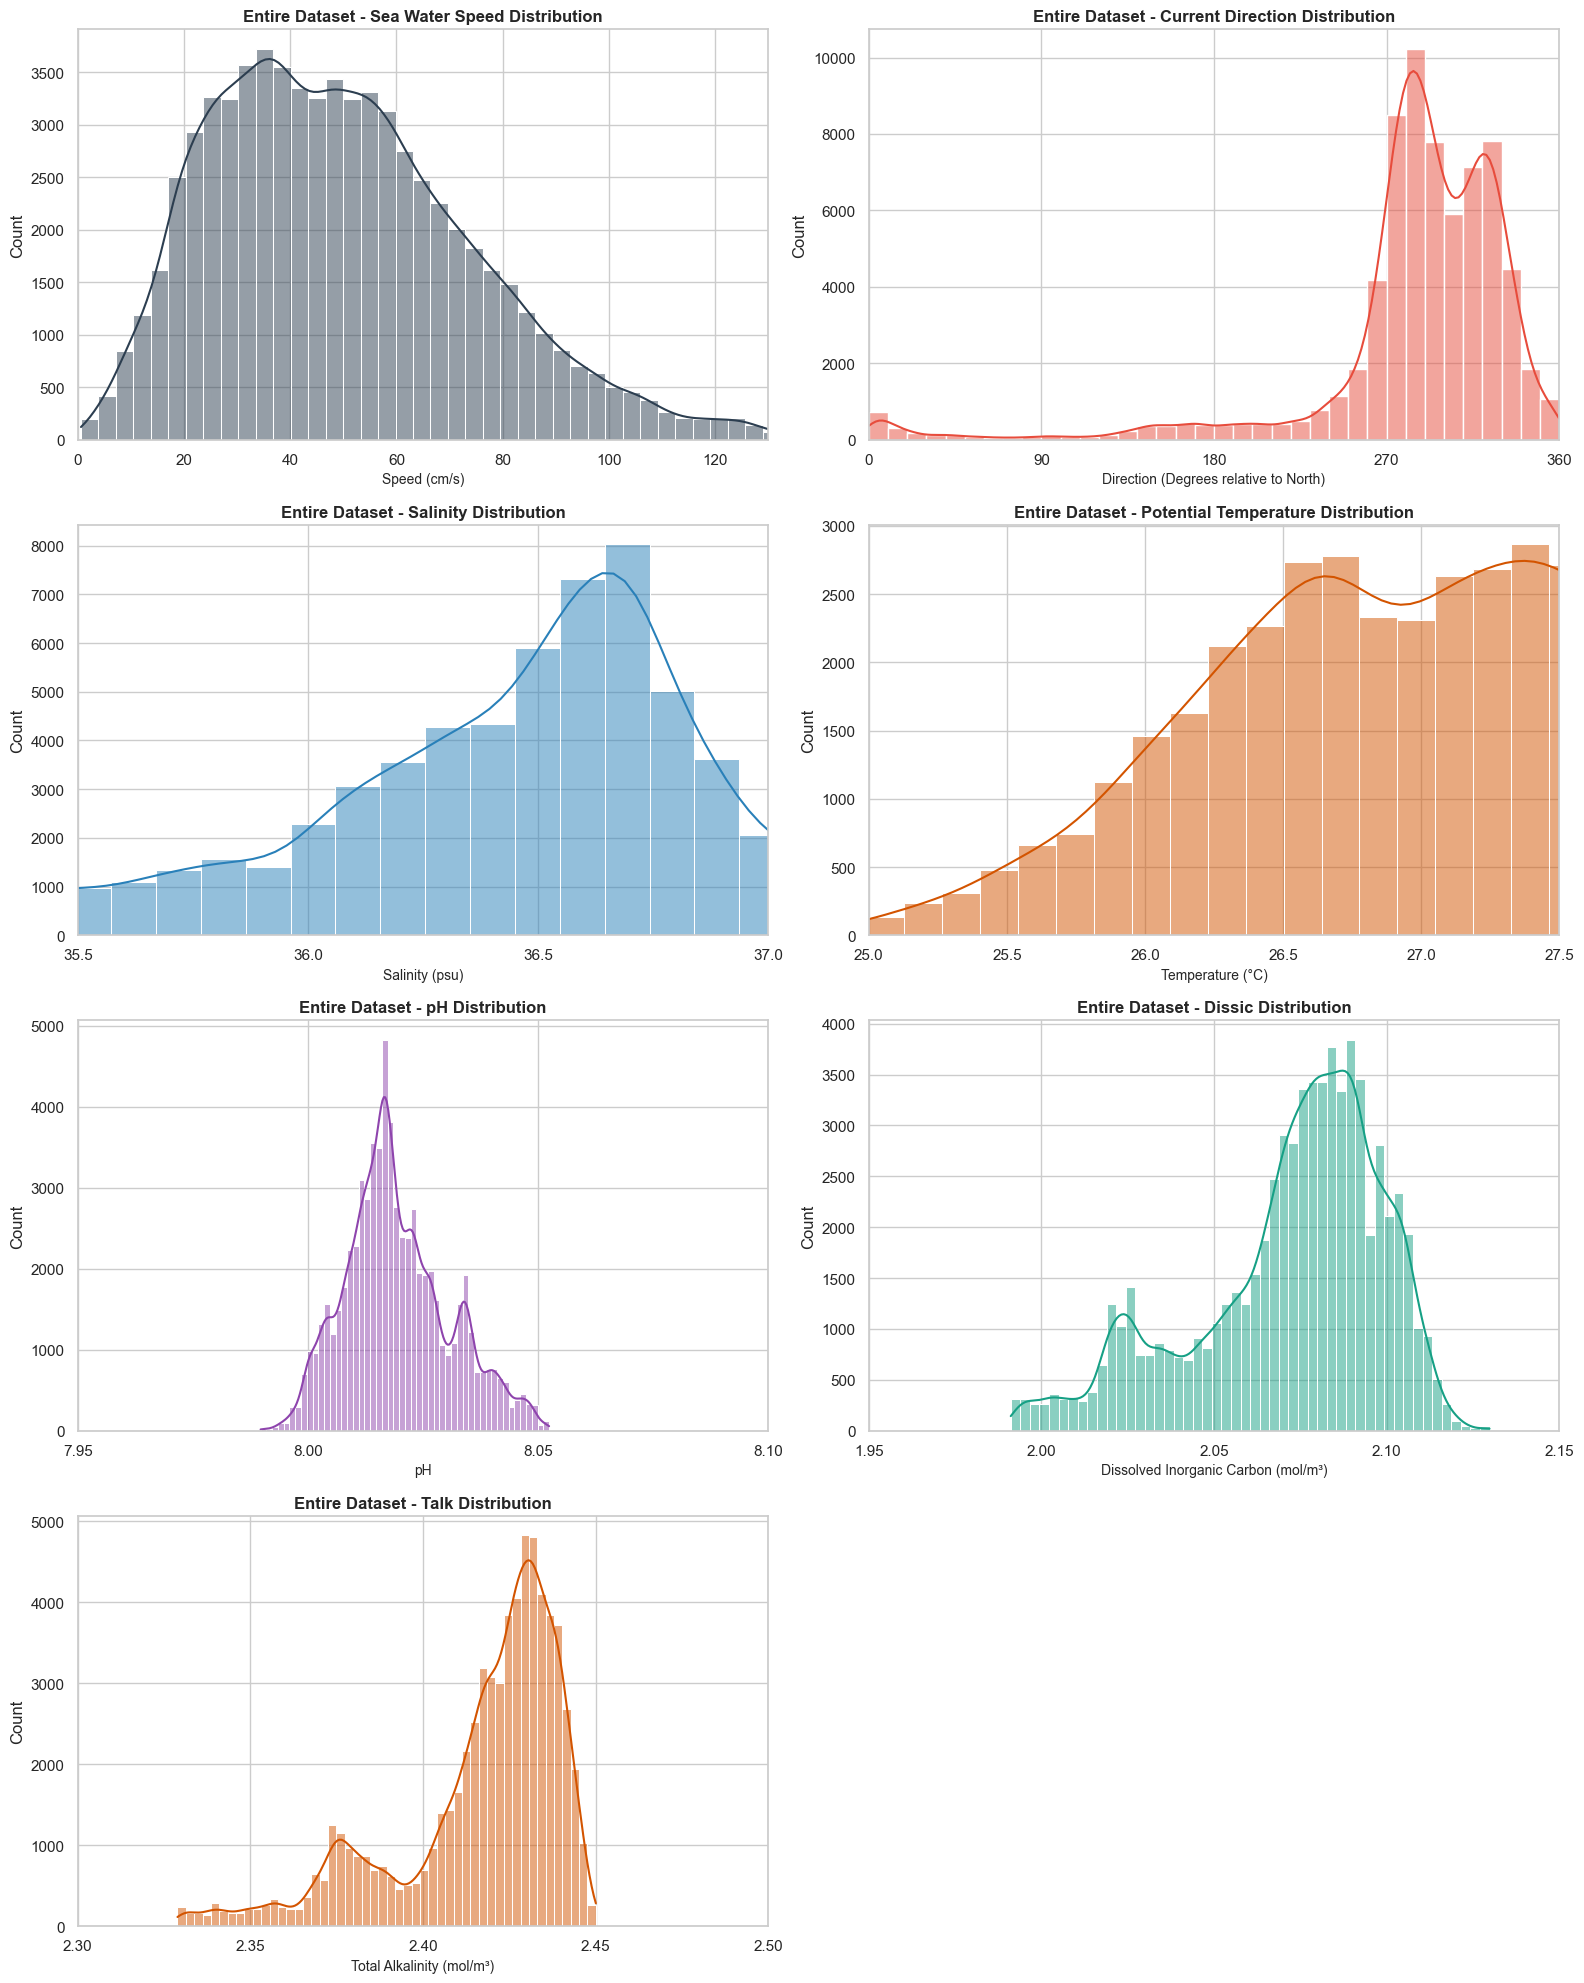

In [6]:
# Set visual style
sns.set_theme(style='whitegrid')

# Create a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# 1. Speed Histogram
sns.histplot(data=df, x='speed_cms', bins=50, kde=True, ax=axes[0, 0], color='#2c3e50')
axes[0, 0].set_title('Entire Dataset - Sea Water Speed Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Speed (cm/s)', fontsize=10)
axes[0, 0].set_xlim(0, 130)
axes[0, 0].set_xticks([0, 20, 40, 60, 80, 100, 120])

# 2. Direction Histogram
sns.histplot(data=df, x='direction', bins=36, kde=True, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Entire Dataset - Current Direction Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Direction (Degrees relative to North)', fontsize=10)
axes[0, 1].set_xlim(0, 360)
axes[0, 1].set_xticks([0, 90, 180, 270, 360])

# 3. Salinity Histogram
sns.histplot(data=df, x='so', bins=50, kde=True, ax=axes[1, 0], color='#2980b9')
axes[1, 0].set_title('Entire Dataset - Salinity Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Salinity (psu)', fontsize=10)
axes[1, 0].set_xlim(35.5, 37.0)
axes[1, 0].set_xticks([35.5, 36.0, 36.5, 37.0])

# 4. Temperature Histogram
sns.histplot(data=df, x='thetao', bins=50, kde=True, ax=axes[1, 1], color='#d35400')
axes[1, 1].set_title('Entire Dataset - Potential Temperature Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 1].set_xlim(25.0, 27.5)
axes[1, 1].set_xticks([25.0, 25.5, 26.0, 26.5, 27.0, 27.5])

# 5. pH Histogram
sns.histplot(data=df, x='ph', bins=50, kde=True, ax=axes[2, 0], color='#8e44ad')
axes[2, 0].set_title('Entire Dataset - pH Distribution', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('pH', fontsize=10)
axes[2, 0].set_xlim(7.95, 8.10)
axes[2, 0].set_xticks([7.95, 8.0, 8.05, 8.10])

# 6. Dissic Histogram
sns.histplot(data=df, x='dissic', bins=50, kde=True, ax=axes[2, 1], color='#16a085')
axes[2, 1].set_title('Entire Dataset - Dissic Distribution', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Dissolved Inorganic Carbon (mol/m³)', fontsize=10)
axes[2, 1].set_xlim(1.95, 2.15)
axes[2, 1].set_xticks([1.95, 2.0, 2.05, 2.1, 2.15])

# 7. Talk Histogram
sns.histplot(data=df, x='talk', bins=50, kde=True, ax=axes[3, 0], color='#d35400')
axes[3, 0].set_title('Entire Dataset - Talk Distribution', fontsize=12, fontweight='bold')
axes[3, 0].set_xlabel('Total Alkalinity (mol/m³)', fontsize=10)
axes[3, 0].set_xlim(2.3, 2.5)
axes[3, 0].set_xticks([2.3, 2.35, 2.4, 2.45, 2.5])

# Hide the 8th subplot (axes[3, 1])
axes[3, 1].set_visible(False)

plt.tight_layout()
plt.show()

### 6. Monthly Distributions (Entire Dataset)
Box plots of Speed, Direction, Salinity, Temperature, pH, Dissic, and Talk grouped by calendar month to show seasonal trends chronologically across all 48 months.

C:\Users\chris\AppData\Local\Temp\ipykernel_47156\1737276654.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
C:\Users\chris\AppData\Local\Temp\ipykernel_47156\1737276654.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chris\AppData\Local\Temp\ipykernel_47156\1737276654.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
C:\Users\chris\Ap

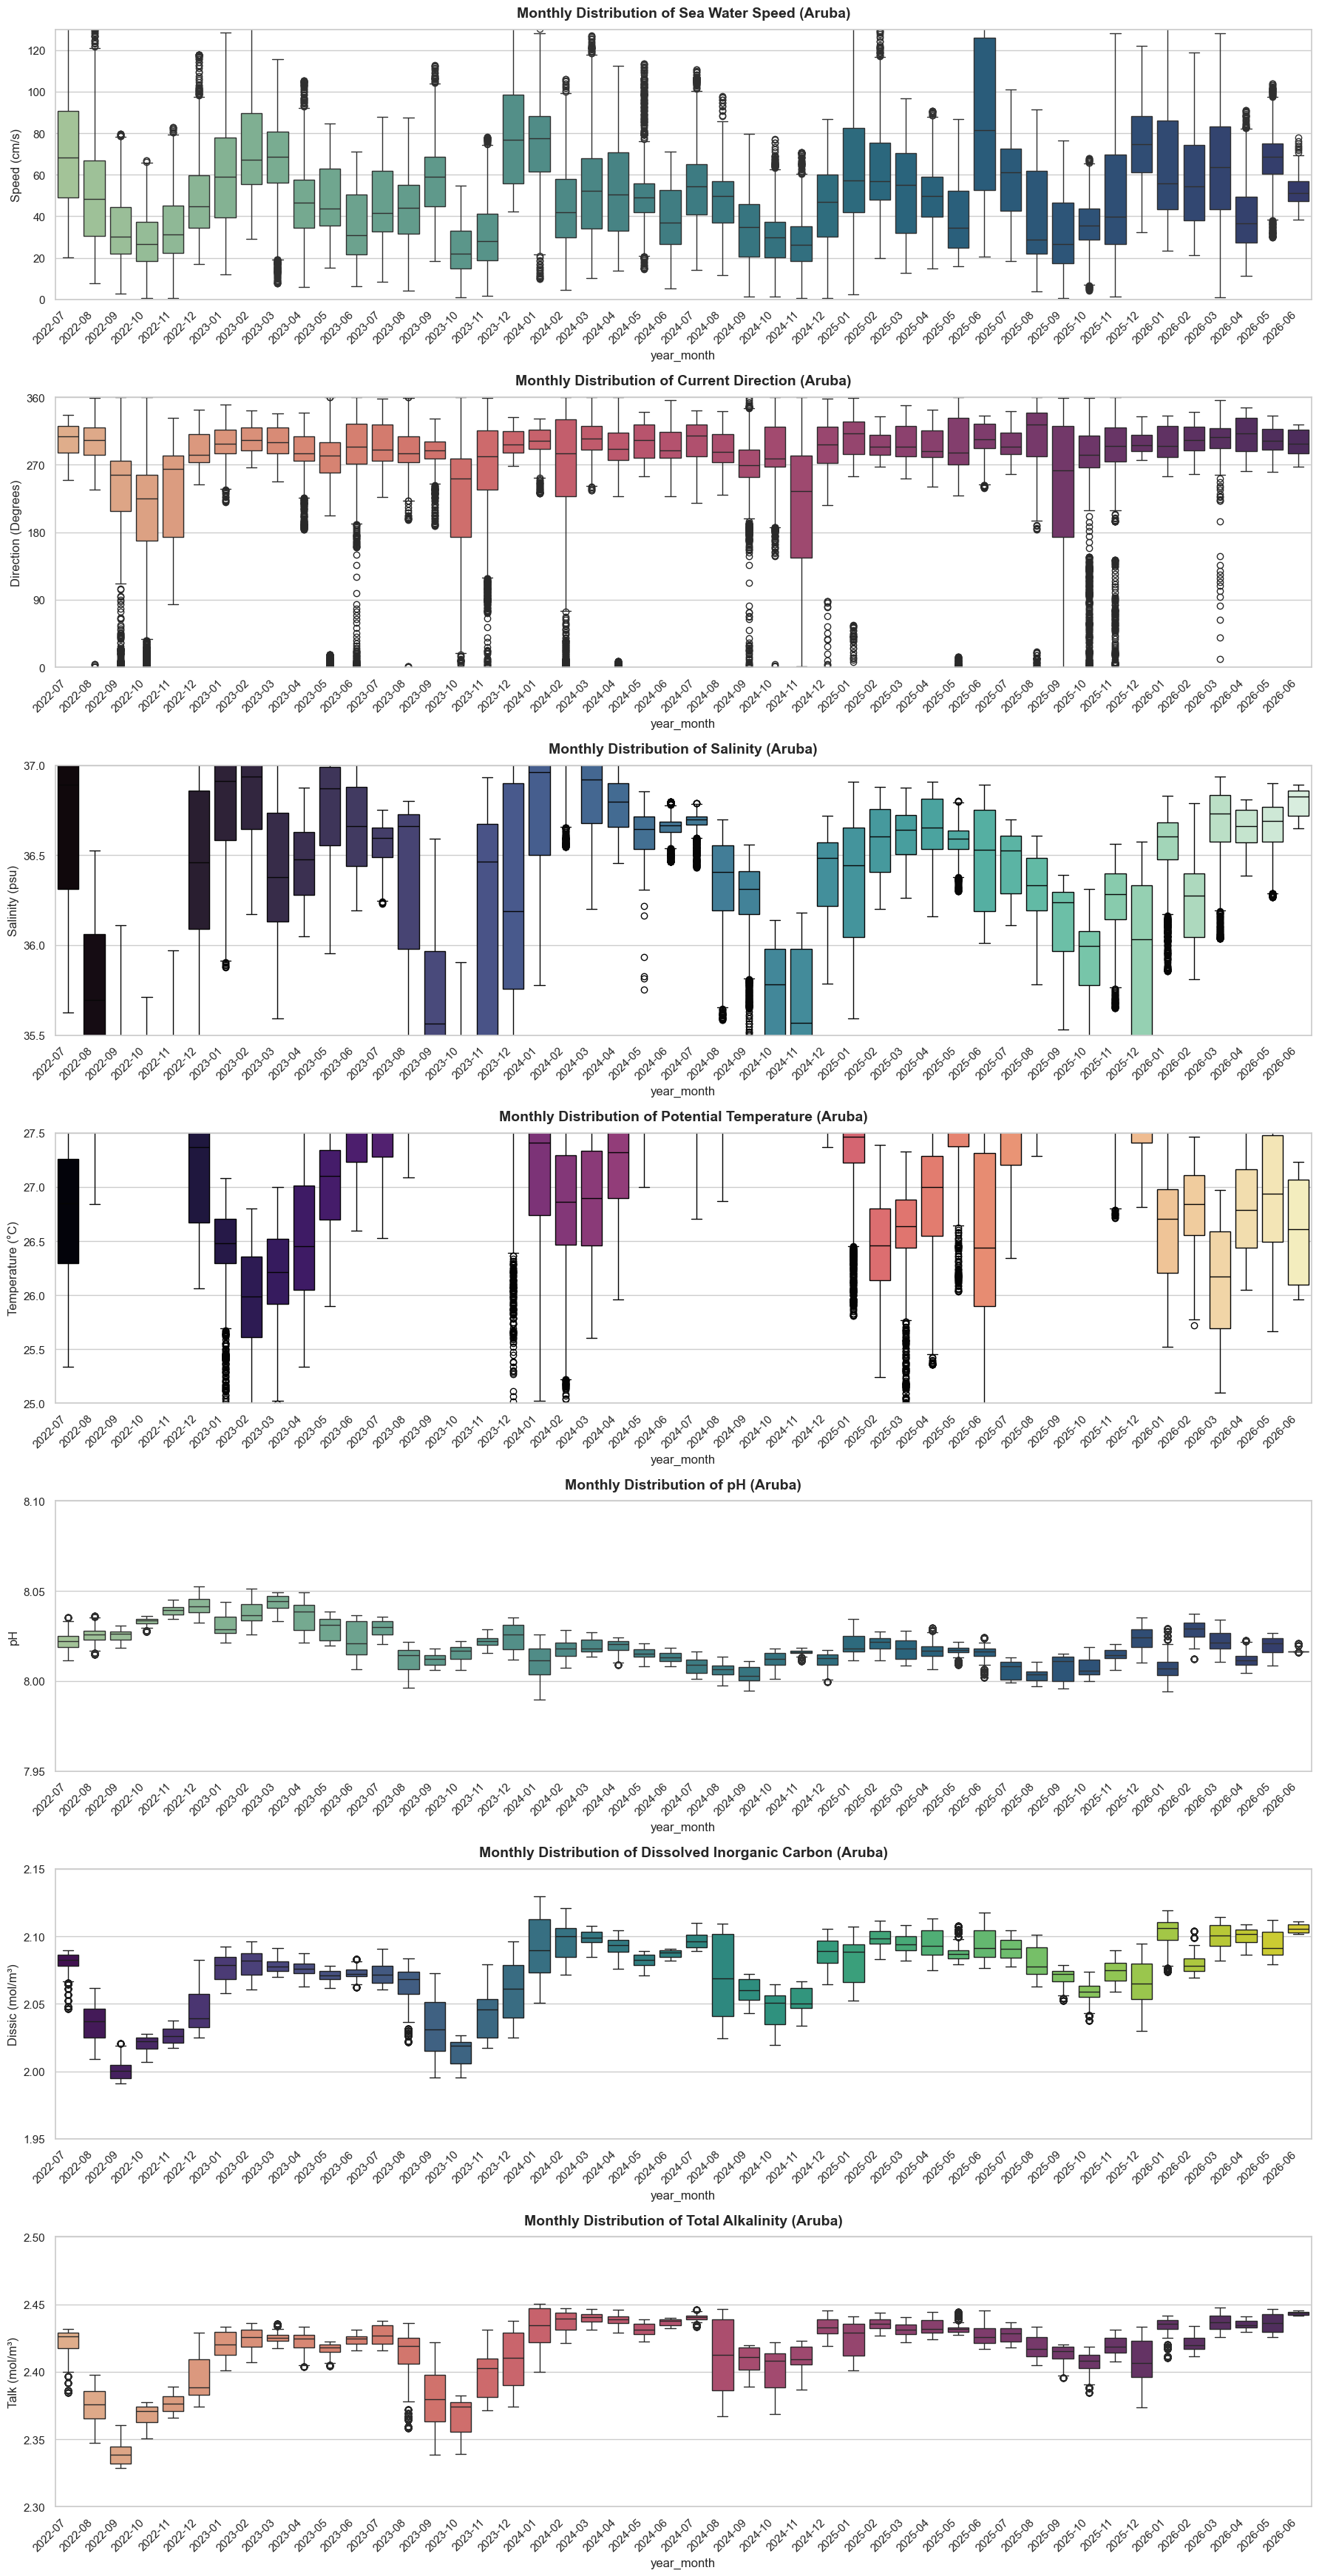

In [7]:
# Create sorted Year-Month string column for grouping
df['year_month'] = df['time'].dt.strftime('%Y-%m')
sorted_months = sorted(df['year_month'].unique())

# Setup figure with 7 vertical subplots
fig, axes = plt.subplots(7, 1, figsize=(18, 35))

# 1. Speed Boxplot
sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
axes[0].set_title('Monthly Distribution of Sea Water Speed (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Speed (cm/s)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 130)
axes[0].set_yticks([0, 20, 40, 60, 80, 100, 120])

# 2. Direction Boxplot
sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
axes[1].set_title('Monthly Distribution of Current Direction (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Direction (Degrees)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])

# 3. Salinity Boxplot
sns.boxplot(data=df, x='year_month', y='so', ax=axes[2], palette='mako', order=sorted_months)
axes[2].set_title('Monthly Distribution of Salinity (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[2].set_ylabel('Salinity (psu)', fontsize=12)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(35.5, 37.0)
axes[2].set_yticks([35.5, 36.0, 36.5, 37.0])

# 4. Temperature Boxplot
sns.boxplot(data=df, x='year_month', y='thetao', ax=axes[3], palette='magma', order=sorted_months)
axes[3].set_title('Monthly Distribution of Potential Temperature (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[3].set_ylabel('Temperature (°C)', fontsize=12)
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=45, ha='right')
axes[3].set_ylim(25.0, 27.5)
axes[3].set_yticks([25.0, 25.5, 26.0, 26.5, 27.0, 27.5])

# 5. pH Boxplot
sns.boxplot(data=df, x='year_month', y='ph', ax=axes[4], palette='crest', order=sorted_months)
axes[4].set_title('Monthly Distribution of pH (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[4].set_ylabel('pH', fontsize=12)
axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45, ha='right')
axes[4].set_ylim(7.95, 8.10)
axes[4].set_yticks([7.95, 8.0, 8.05, 8.10])

# 6. Dissic Boxplot
sns.boxplot(data=df, x='year_month', y='dissic', ax=axes[5], palette='viridis', order=sorted_months)
axes[5].set_title('Monthly Distribution of Dissolved Inorganic Carbon (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[5].set_ylabel('Dissic (mol/m³)', fontsize=12)
axes[5].set_xticklabels(axes[5].get_xticklabels(), rotation=45, ha='right')
axes[5].set_ylim(1.95, 2.15)
axes[5].set_yticks([1.95, 2.0, 2.05, 2.1, 2.15])

# 7. Talk Boxplot
sns.boxplot(data=df, x='year_month', y='talk', ax=axes[6], palette='flare', order=sorted_months)
axes[6].set_title('Monthly Distribution of Total Alkalinity (Aruba)', fontsize=14, fontweight='bold', pad=12)
axes[6].set_ylabel('Talk (mol/m³)', fontsize=12)
axes[6].set_xticklabels(axes[6].get_xticklabels(), rotation=45, ha='right')
axes[6].set_ylim(2.3, 2.5)
axes[6].set_yticks([2.3, 2.35, 2.4, 2.45, 2.5])

plt.tight_layout()
plt.show()

### 7. Subset the Dataset into Years
Divide the dataset into chronological 12-month periods from the start timestamp (`2022-07-04`):
- **`year1`**: July 4, 2022 – July 4, 2023 (12 months)
- **`year2`**: July 4, 2023 – July 4, 2024 (12 months)
- **`year3`**: July 4, 2024 – July 4, 2025 (12 months)
- **`year4`**: July 4, 2025 – June 4, 2026 (remaining 11 months)

In [8]:
# Ensure time column is datetime objects
df['time'] = pd.to_datetime(df['time'])

# Define start date of the dataset
start_date = df['time'].min()

# Define 12-month boundary offsets
y1_end = start_date + pd.DateOffset(years=1)
y2_end = start_date + pd.DateOffset(years=2)
y3_end = start_date + pd.DateOffset(years=3)

# Subset into distinct copies
year1 = df[(df['time'] >= start_date) & (df['time'] < y1_end)].copy()
year2 = df[(df['time'] >= y1_end) & (df['time'] < y2_end)].copy()
year3 = df[(df['time'] >= y2_end) & (df['time'] < y3_end)].copy()
year4 = df[(df['time'] >= y3_end)].copy()  # Spans the remaining 11 months

# Print range and shapes
years_dfs = [year1, year2, year3, year4]
for i, y_df in enumerate(years_dfs, 1):
    label = f'Year {i}' if i < 4 else 'Year 4 (11 months)'
    print(f'{label}: {y_df["time"].min()} to {y_df["time"].max()} | Shape: {y_df.shape}')

Year 1: 2022-07-05 00:00:00 to 2023-07-04 23:00:00 | Shape: (17520, 18)
Year 2: 2023-07-05 00:00:00 to 2024-07-04 23:00:00 | Shape: (17568, 18)
Year 3: 2024-07-05 00:00:00 to 2025-07-04 23:00:00 | Shape: (17520, 18)
Year 4 (11 months): 2025-07-05 00:00:00 to 2026-06-04 12:00:00 | Shape: (16058, 18)


### 8. Summary Statistics by Year
Descriptive statistics for each subsetted year.

In [9]:
for i, y_df in enumerate(years_dfs, 1):
    label = f'Year {i}' if i < 4 else 'Year 4 (11-Month remaining)'
    print(f'\n{"="*20} {label} Summary Statistics {"="*20}')
    display(y_df[['uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao', 'ph', 'dissic', 'talk']].describe())


==================== Year 1 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,-0.353580,0.203713,49.458878,274.878754,36.082405,27.472240,8.032372,2.055198,2.400743
std,0.226287,0.304839,25.695820,64.882111,0.988984,1.267064,0.009182,0.028201,0.029260
min,-0.927483,-0.586683,0.686358,0.001587,32.841969,24.577477,8.006477,1.991114,2.328858
25%,-0.511916,0.003195,29.905988,266.036148,35.491108,26.463639,8.025707,2.027876,2.376324
50%,-0.354142,0.136980,45.163858,286.954224,36.366045,27.291780,8.033469,2.068968,2.415491
75%,-0.209288,0.388191,65.395746,314.190399,36.845743,28.488830,8.039315,2.077855,2.424818
max,0.308472,1.277682,144.517166,359.976440,37.717453,30.775398,8.052398,2.096122,2.435920



==================== Year 2 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
count,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000
mean,-0.371732,0.228569,50.175018,284.475891,36.400230,28.200710,8.017245,2.069532,2.417515
std,0.221170,0.276533,25.309742,53.570717,0.696404,1.206845,0.007489,0.030018,0.027253
min,-1.086100,-0.490478,1.105185,0.068970,34.401127,25.014467,7.989708,1.995630,2.338567
25%,-0.525893,0.042801,31.383418,275.215736,36.095561,27.335129,8.012990,2.049096,2.400688
50%,-0.371514,0.162460,48.093832,291.335449,36.640060,28.161509,8.017039,2.078387,2.428588
75%,-0.228151,0.378939,64.133265,315.821945,36.835629,28.892763,8.021914,2.090309,2.437687
max,0.479030,1.414457,165.142136,359.997894,37.505733,31.442373,8.035587,2.129844,2.450076



==================== Year 3 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,-0.363092,0.235384,49.778553,286.609741,36.346031,28.009222,8.013681,2.080194,2.423805
std,0.207538,0.297937,26.699526,49.137848,0.427290,1.386639,0.006948,0.021791,0.016300
min,-0.953193,-0.400038,0.587690,0.058716,34.760059,24.895451,7.994728,2.019405,2.367116
25%,-0.493642,0.023446,30.306252,273.114677,36.137128,26.943698,8.009374,2.063421,2.415039
50%,-0.365440,0.146424,46.720959,290.404938,36.497852,27.784998,8.014755,2.086940,2.428740
75%,-0.232977,0.402657,62.294637,318.693329,36.656409,29.241081,8.017679,2.096639,2.435511
max,0.325570,1.445309,163.888199,359.985229,36.905685,31.450548,8.034501,2.117731,2.446282



==================== Year 4 (11-Month remaining) Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao,ph,dissic,talk
count,16058.000000,16058.000000,16058.000000,16058.000000,16058.000000,16058.000000,16058.000000,16058.000000,16058.000000
mean,-0.373518,0.289872,52.502613,289.900665,36.335018,27.557615,8.013902,2.083510,2.423229
std,0.225119,0.250023,24.713549,59.264175,0.383333,1.077698,0.009519,0.017904,0.013655
min,-1.054082,-0.288872,0.619486,0.003632,34.755840,25.095079,7.994342,2.029903,2.373370
25%,-0.526719,0.095871,33.170059,282.222343,36.144371,26.728692,8.006207,2.070568,2.413957
50%,-0.357865,0.243092,49.557159,298.913452,36.381073,27.484858,8.012962,2.084224,2.425513
75%,-0.229409,0.476190,70.322128,320.693115,36.614817,28.258340,8.020658,2.098230,2.433666
max,0.339302,1.117823,130.973358,359.998474,36.935955,30.923885,8.037391,2.118959,2.447598


### 9. Visualizing Year-by-Year Distributions (4x7 Grid of Histograms)
Compare the distributions of all 7 variables across all 4 years.

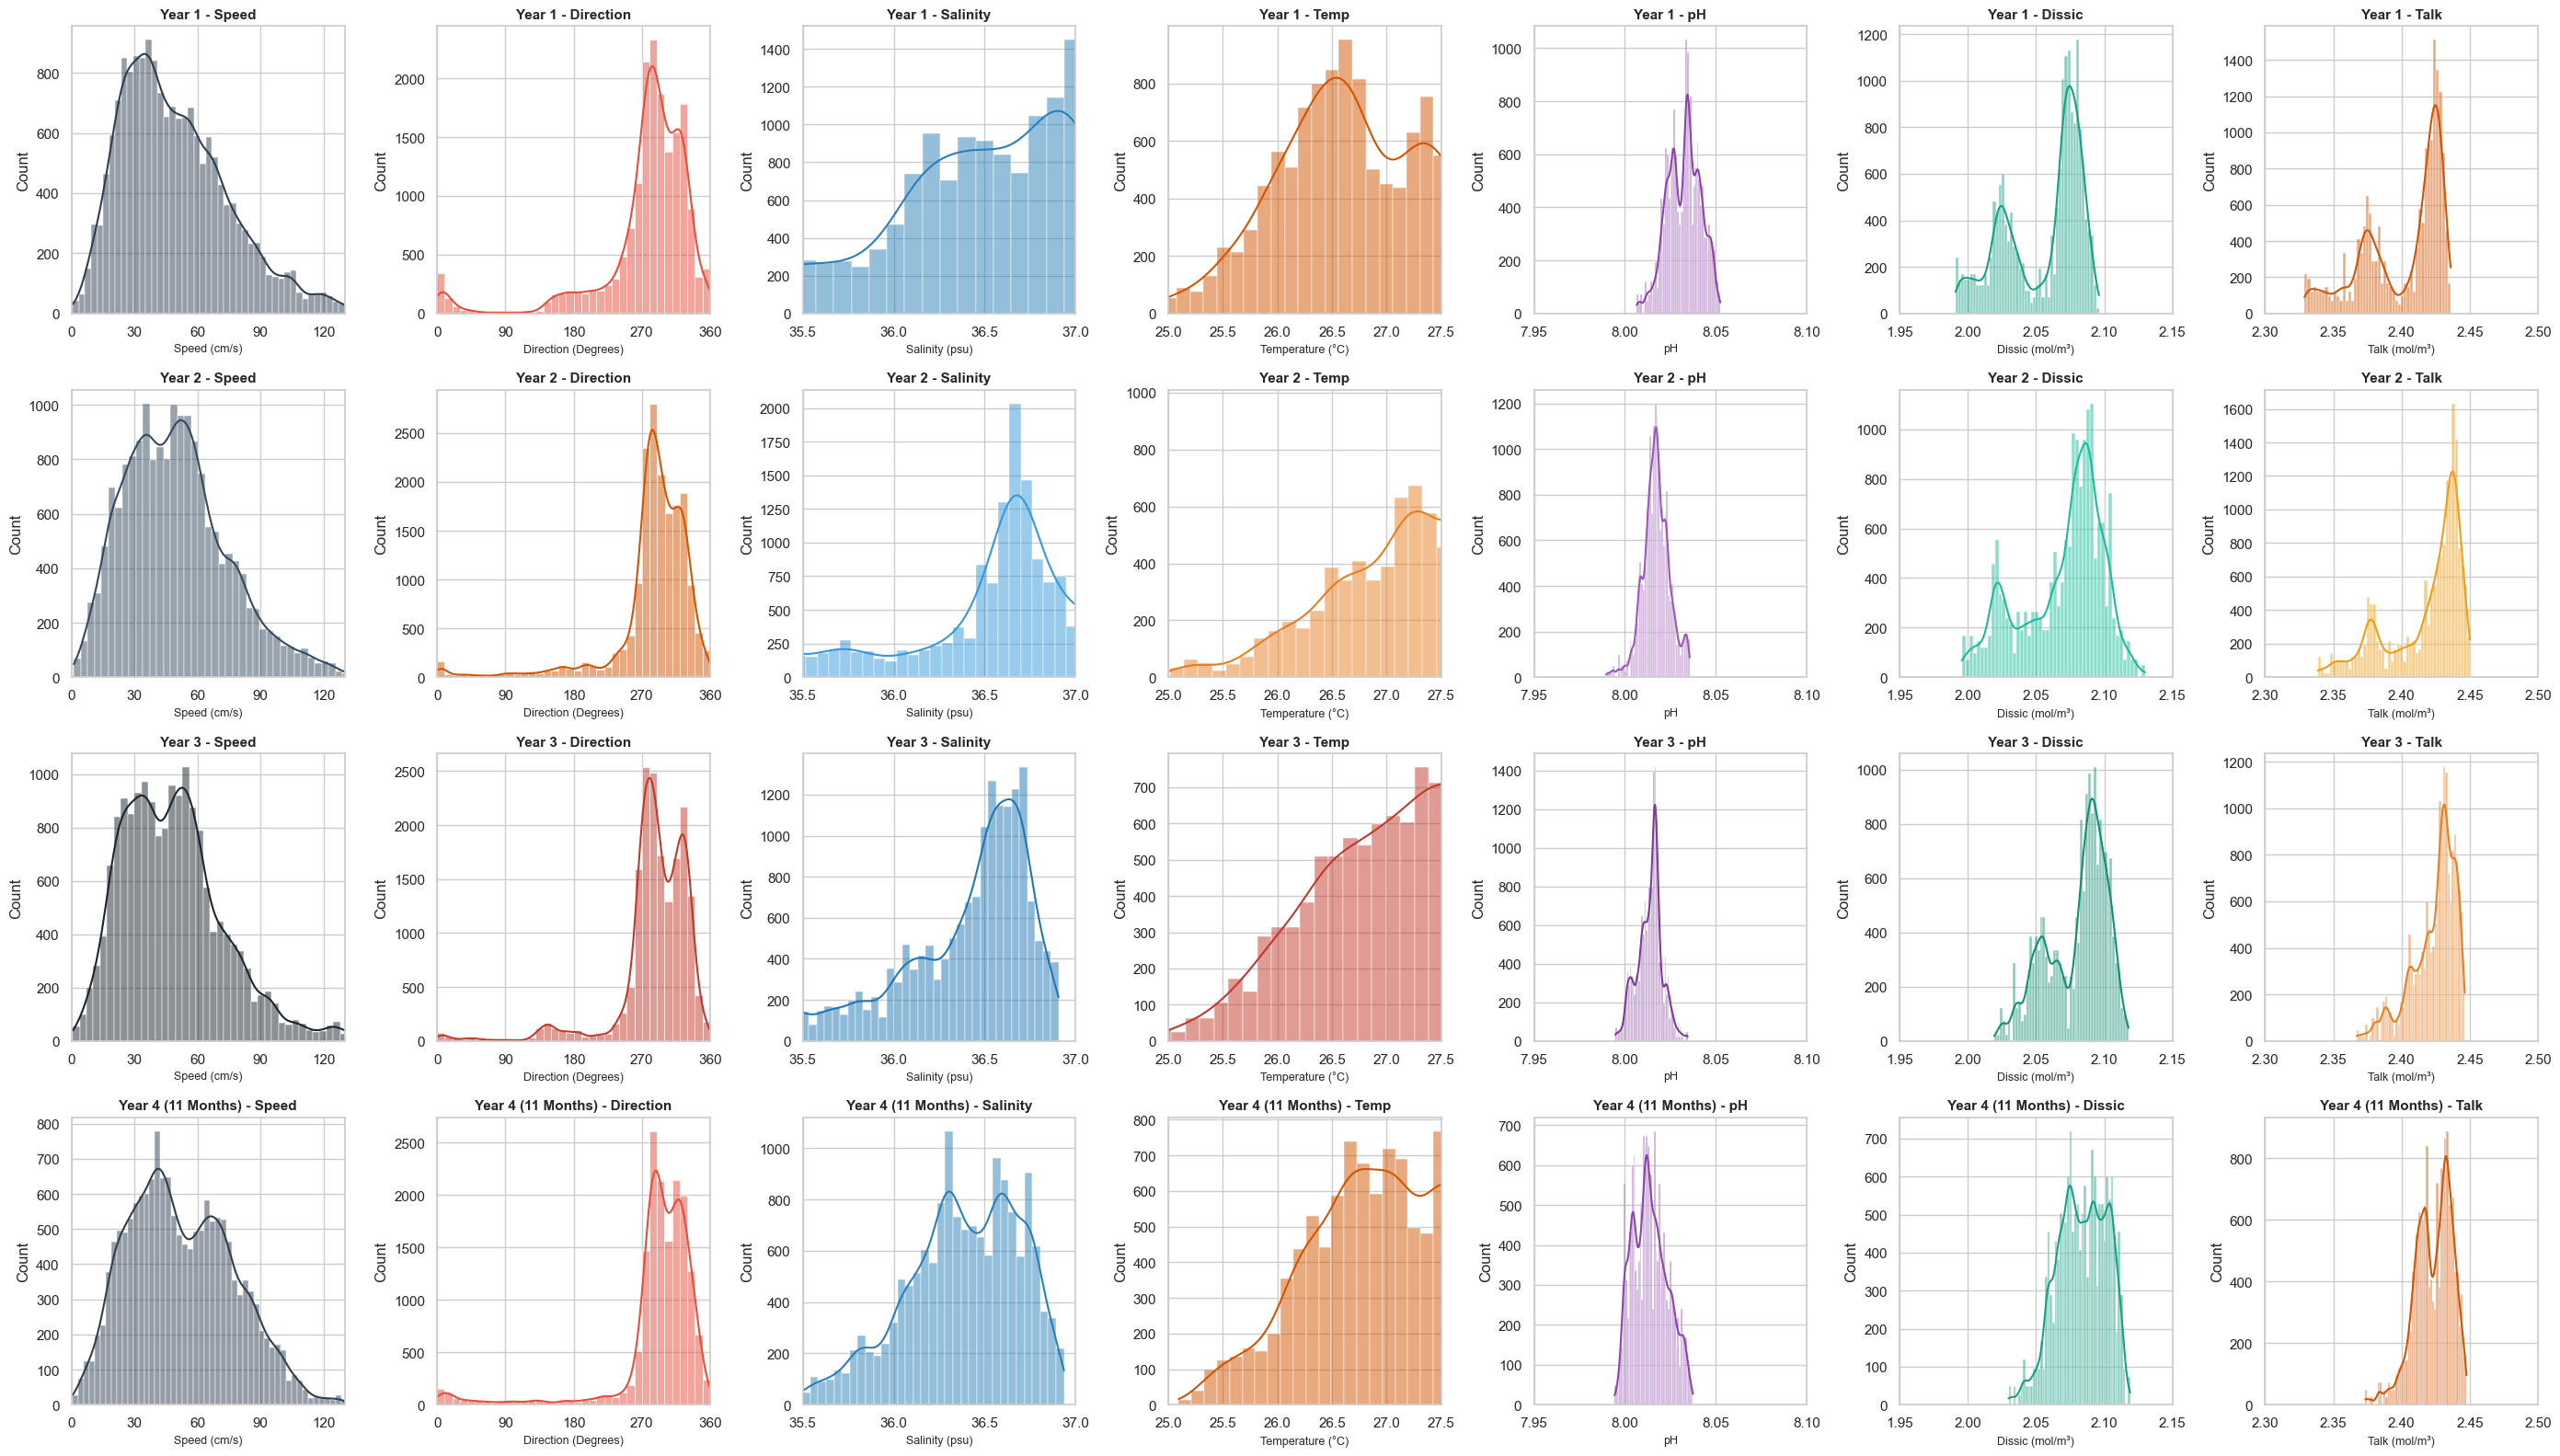

In [10]:
# Set visual style
sns.set_theme(style='whitegrid')

# Create a 4x7 grid of subplots
fig, axes = plt.subplots(4, 7, figsize=(28, 16))

colors_speed = ['#2c3e50', '#34495e', '#1a252f', '#2c3e50']
colors_dir = ['#e74c3c', '#d35400', '#c0392b', '#e74c3c']
colors_sal = ['#2980b9', '#3498db', '#1f77b4', '#2980b9']
colors_temp = ['#d35400', '#e67e22', '#c0392b', '#d35400']
colors_ph = ['#8e44ad', '#9b59b6', '#7d3c98', '#8e44ad']
colors_dic = ['#16a085', '#1abc9c', '#118f73', '#16a085']
colors_alk = ['#d35400', '#f39c12', '#e67e22', '#d35400']

for i, y_df in enumerate(years_dfs):
    year_label = f'Year {i+1}' if i < 3 else 'Year 4 (11 Months)'
    
    # 1. Speed (Col 1)
    sns.histplot(data=y_df, x='speed_cms', bins=50, kde=True, ax=axes[i, 0], color=colors_speed[i])
    axes[i, 0].set_title(f'{year_label} - Speed', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('Speed (cm/s)', fontsize=9)
    axes[i, 0].set_xlim(0, 130)
    axes[i, 0].set_xticks([0, 30, 60, 90, 120])
    
    # 2. Direction (Col 2)
    sns.histplot(data=y_df, x='direction', bins=36, kde=True, ax=axes[i, 1], color=colors_dir[i])
    axes[i, 1].set_title(f'{year_label} - Direction', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('Direction (Degrees)', fontsize=9)
    axes[i, 1].set_xlim(0, 360)
    axes[i, 1].set_xticks([0, 90, 180, 270, 360])
    
    # 3. Salinity (Col 3)
    sns.histplot(data=y_df, x='so', bins=50, kde=True, ax=axes[i, 2], color=colors_sal[i])
    axes[i, 2].set_title(f'{year_label} - Salinity', fontsize=11, fontweight='bold')
    axes[i, 2].set_xlabel('Salinity (psu)', fontsize=9)
    axes[i, 2].set_xlim(35.5, 37.0)
    axes[i, 2].set_xticks([35.5, 36.0, 36.5, 37.0])
    
    # 4. Temperature (Col 4)
    sns.histplot(data=y_df, x='thetao', bins=50, kde=True, ax=axes[i, 3], color=colors_temp[i])
    axes[i, 3].set_title(f'{year_label} - Temp', fontsize=11, fontweight='bold')
    axes[i, 3].set_xlabel('Temperature (°C)', fontsize=9)
    axes[i, 3].set_xlim(25.0, 27.5)
    axes[i, 3].set_xticks([25.0, 25.5, 26.0, 26.5, 27.0, 27.5])

    # 5. pH (Col 5)
    sns.histplot(data=y_df, x='ph', bins=50, kde=True, ax=axes[i, 4], color=colors_ph[i])
    axes[i, 4].set_title(f'{year_label} - pH', fontsize=11, fontweight='bold')
    axes[i, 4].set_xlabel('pH', fontsize=9)
    axes[i, 4].set_xlim(7.95, 8.10)
    axes[i, 4].set_xticks([7.95, 8.0, 8.05, 8.10])

    # 6. Dissic (Col 6)
    sns.histplot(data=y_df, x='dissic', bins=50, kde=True, ax=axes[i, 5], color=colors_dic[i])
    axes[i, 5].set_title(f'{year_label} - Dissic', fontsize=11, fontweight='bold')
    axes[i, 5].set_xlabel('Dissic (mol/m³)', fontsize=9)
    axes[i, 5].set_xlim(1.95, 2.15)
    axes[i, 5].set_xticks([1.95, 2.0, 2.05, 2.1, 2.15])

    # 7. Talk (Col 7)
    sns.histplot(data=y_df, x='talk', bins=50, kde=True, ax=axes[i, 6], color=colors_alk[i])
    axes[i, 6].set_title(f'{year_label} - Talk', fontsize=11, fontweight='bold')
    axes[i, 6].set_xlabel('Talk (mol/m³)', fontsize=9)
    axes[i, 6].set_xlim(2.3, 2.5)
    axes[i, 6].set_xticks([2.3, 2.35, 2.4, 2.45, 2.5])

plt.tight_layout()
plt.show()

### 10. Dataset Duration Verification
Calculates total temporal coverage.

In [11]:
from dateutil.relativedelta import relativedelta

start_date = pd.to_datetime(df['time'].min())
end_date = pd.to_datetime(df['time'].max())
diff = relativedelta(end_date, start_date)

print(f'Start Date: {start_date}')
print(f'End Date:   {end_date}')
print(f'Total Duration: {diff.years} years, {diff.months} months, and {diff.days} days')

Start Date: 2022-07-05 00:00:00
End Date:   2026-06-04 12:00:00
Total Duration: 3 years, 10 months, and 30 days
